In [15]:
%pip install yfinance
%pip install statsmodels
%pip install matplotlib
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
Stock_A = 'HDFCBANK.NS'
Stock_B = 'ICICIBANK.NS'
period = '3y'
print('PAIRS TRADING: HDFC BANK vs ICICI BANK"')
print('='*67)

83489.28s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


83495.23s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


83501.04s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
PAIRS TRADING: HDFC BANK vs ICICI BANK"


In [16]:
data = yf.download([Stock_A,Stock_B],period = period,auto_adjust = True)
close = raw['Close'].dropna()
close.columns = ['HDFC','ICICI']
print(f"data shape: {close.shape}")
print(f"from :{close.index[0].date()}")
print(f"to : {close.index[-1].date()}")
print(f"total days : {len(close)}")

[*********************100%***********************]  2 of 2 completed

data shape: (741, 2)
from :2023-05-22
to : 2026-05-20
total days : 741


correlation analysis


/var/folders/4k/lw9wr0jx5ms1xxpgzn3x_nkc0000gn/T/ipykernel_54618/4193048098.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hedge_ratio = model.params[1]



 Running correlation analysis & cointegeration tests
correlation : 0.8253
cointegeration p-value : 0.4942
hedge ratio : 1.5730
spread half-life : 58.00 days


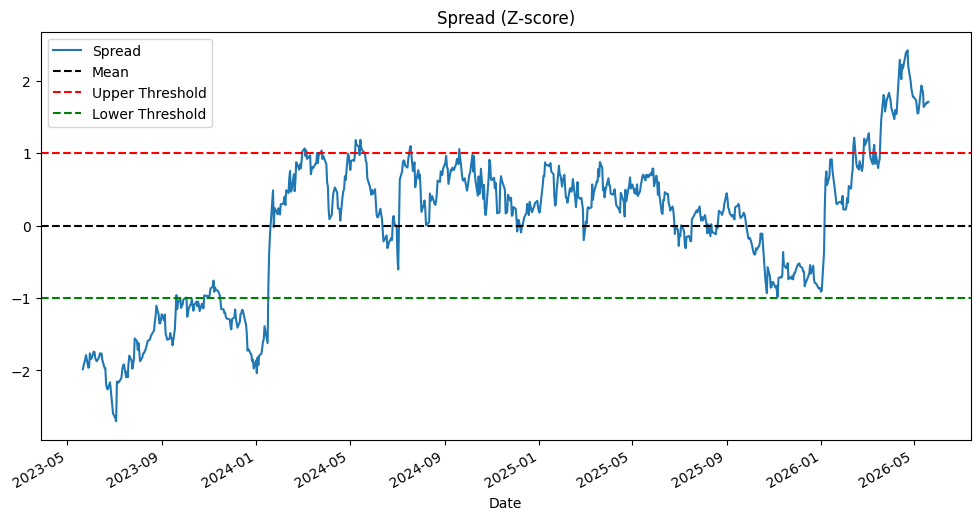

In [17]:
print("\n Running correlation analysis & cointegeration tests")
corr              = close["HDFC"].corr(close["ICICI"])
score, pvalue, _  = coint(close["HDFC"], close["ICICI"])
X = add_constant(close['HDFC'])
model = OLS(close['ICICI'], X).fit()
hedge_ratio = model.params[1]
print(f"correlation : {corr:.4f}")
print(f"cointegeration p-value : {pvalue:.4f}")
print(f"hedge ratio : {hedge_ratio:.4f}")
spread_raw = close['ICICI'] - hedge_ratio * close['HDFC']
lag = spread_raw.shift(1).dropna()
diff = spread_raw.diff().dropna()
ols2  = OLS(diff, add_constant(lag)).fit()
half_life = int(-np.log(2) / ols2.params.iloc[1])
print(f"spread half-life : {half_life:.2f} days")
spread = (spread_raw - spread_raw.mean()) / spread_raw.std()
spread.plot(figsize=(12,6))
plt.title("Spread (Z-score)")
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='red', linestyle='--')
plt.axhline(-1, color='green', linestyle='--')
plt.legend(['Spread', 'Mean', 'Upper Threshold', 'Lower Threshold'])
plt.show()

entry and exit stategy


In [22]:
print("\n[STEP 4] Building entry/exit signals...")

WINDOW   = 30
ENTRY_Z  = 2.0
EXIT_Z   = 0.5
STOPLOSS = 3.5

close["spread"] = close["HDFC"] - hedge_ratio * close["ICICI"]
close["mean"]   = close["spread"].rolling(WINDOW).mean()
close["std"]    = close["spread"].rolling(WINDOW).std()
close["zscore"] = (close["spread"] - close["mean"]) / close["std"]

close["signal"] = 0
close.loc[close["zscore"] >  ENTRY_Z, "signal"] = -1
close.loc[close["zscore"] < -ENTRY_Z, "signal"] =  1

close["position"] = close["signal"].replace(0, np.nan).ffill().fillna(0)
close.loc[close["zscore"].abs() < EXIT_Z,   "position"] = 0
close.loc[close["zscore"].abs() > STOPLOSS, "position"] = 0

print(f"  Total signals fired : {(close['signal'] != 0).sum()}")



[STEP 4] Building entry/exit signals...
  Total signals fired : 65


BACKEND

In [24]:
print("\n[STEP 5] Running backtest...")

ret_A  = close["HDFC"].pct_change()
ret_B  = close["ICICI"].pct_change()

close["strategy_ret"] = close["position"].shift(1) * (ret_A - ret_B)
close["cum_ret"]      = (1 + close["strategy_ret"]).cumprod()
close["buy_hold_ret"] = (1 + ret_A).cumprod()

total_return  = (close["cum_ret"].iloc[-1] - 1) * 100
annual_return = ((close["cum_ret"].iloc[-1]) ** (252 / len(close)) - 1) * 100
sharpe        = (close["strategy_ret"].mean() / close["strategy_ret"].std()) * np.sqrt(252)
rolling_max   = close["cum_ret"].cummax()
drawdown      = (close["cum_ret"] - rolling_max) / rolling_max
max_drawdown  = drawdown.min() * 100
win_days      = (close["strategy_ret"] > 0).sum()
loss_days     = (close["strategy_ret"] < 0).sum()
win_rate      = win_days / (win_days + loss_days) * 100
num_trades    = (close["position"].diff() != 0).sum()

print("\n" + "=" * 40)
print("  BACKTEST RESULTS")
print("=" * 40)
print(f"  Total Return   : {total_return:+.2f}%")
print(f"  Annual Return  : {annual_return:+.2f}%")
print(f"  Sharpe Ratio   : {sharpe:.2f}")
print(f"  Max Drawdown   : {max_drawdown:.2f}%")
print(f"  Win Rate       : {win_rate:.1f}%")
print(f"  No. of Trades  : {num_trades}")
print("=" * 40)





[STEP 5] Running backtest...

  BACKTEST RESULTS
  Total Return   : +8.47%
  Annual Return  : +2.80%
  Sharpe Ratio   : 0.25
  Max Drawdown   : -22.19%
  Win Rate       : 50.5%
  No. of Trades  : 166


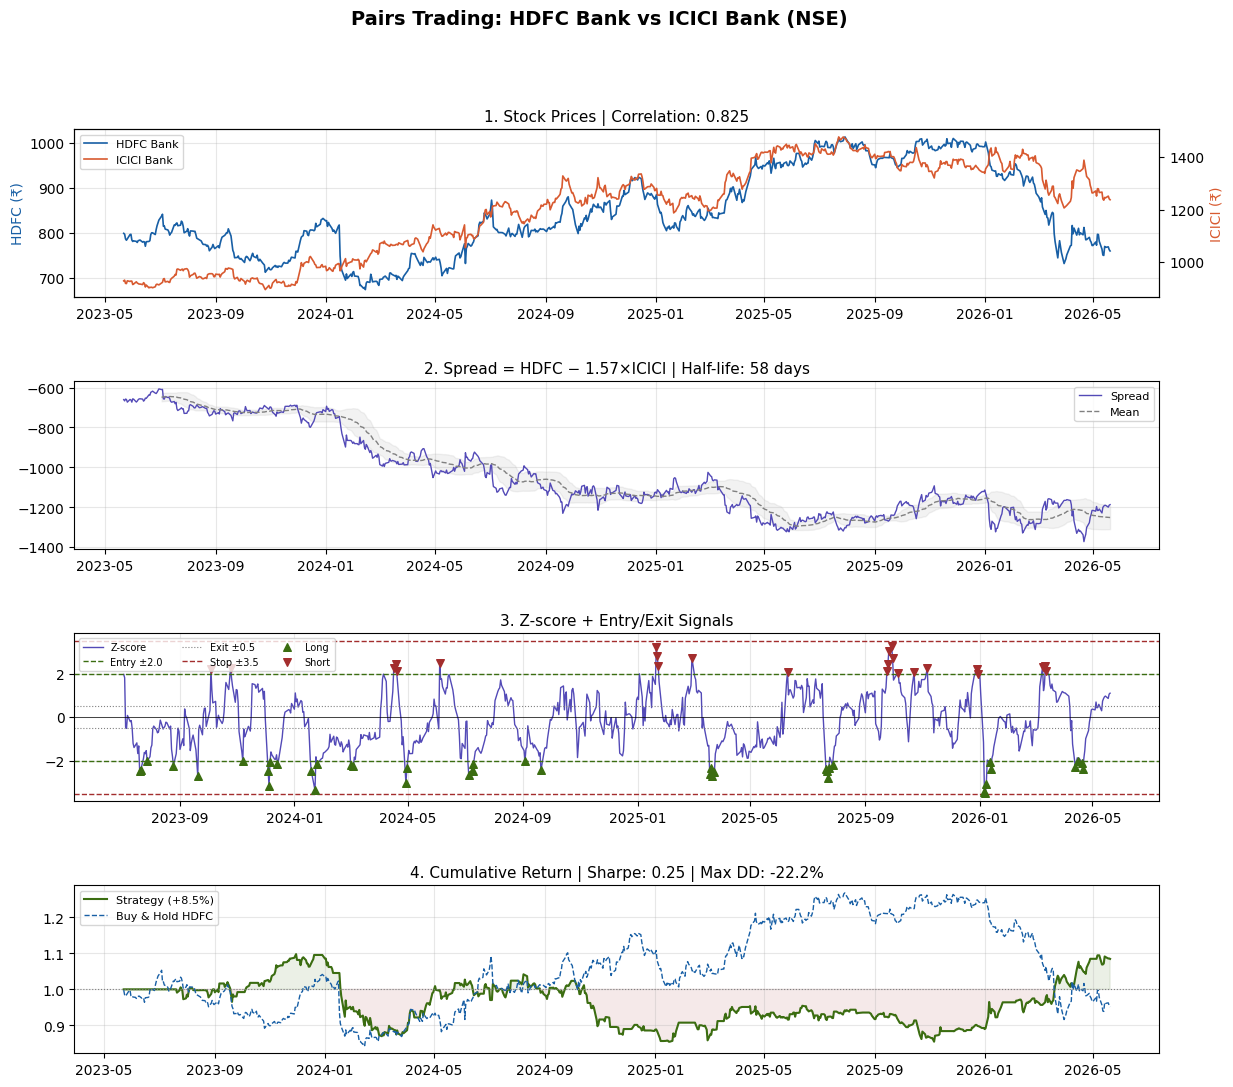


 Done! Chart saved as pairs_trading_hdfc_icici.png


In [26]:
fig = plt.figure(figsize=(14, 12))
fig.suptitle("Pairs Trading: HDFC Bank vs ICICI Bank (NSE)",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(4, 1, figure=fig, hspace=0.5)

ax1  = fig.add_subplot(gs[0])
ax1b = ax1.twinx()
ax1.plot(close.index,  close["HDFC"],  color="#185FA5", label="HDFC Bank",  lw=1.2)
ax1b.plot(close.index, close["ICICI"], color="#D85A30", label="ICICI Bank", lw=1.2)
ax1.set_ylabel("HDFC (₹)",  color="#185FA5")
ax1b.set_ylabel("ICICI (₹)", color="#D85A30")
ax1.set_title(f"1. Stock Prices | Correlation: {corr:.3f}", fontsize=11)
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc="upper left", fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(close.index, close["spread"], color="#534AB7", lw=1,   label="Spread")
ax2.plot(close.index, close["mean"],   color="gray",   lw=1,   linestyle="--", label="Mean")
ax2.fill_between(close.index,
                 close["mean"] - close["std"],
                 close["mean"] + close["std"], alpha=0.1, color="gray")
ax2.set_title(f"2. Spread = HDFC − {hedge_ratio:.2f}×ICICI | Half-life: {half_life} days", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[2])
ax3.plot(close.index, close["zscore"], color="#534AB7", lw=1, label="Z-score")
ax3.axhline( ENTRY_Z,  color="#3B6D11", ls="--", lw=1,   label=f"Entry ±{ENTRY_Z}")
ax3.axhline(-ENTRY_Z,  color="#3B6D11", ls="--", lw=1)
ax3.axhline( EXIT_Z,   color="gray",    ls=":",  lw=0.8, label=f"Exit ±{EXIT_Z}")
ax3.axhline(-EXIT_Z,   color="gray",    ls=":",  lw=0.8)
ax3.axhline( STOPLOSS, color="#A32D2D", ls="--", lw=1,   label=f"Stop ±{STOPLOSS}")
ax3.axhline(-STOPLOSS, color="#A32D2D", ls="--", lw=1)
ax3.axhline(0, color="black", lw=0.5)
longs  = close[close["signal"] ==  1]
shorts = close[close["signal"] == -1]
ax3.scatter(longs.index,  longs["zscore"],  color="#3B6D11", marker="^", s=30, zorder=5, label="Long")
ax3.scatter(shorts.index, shorts["zscore"], color="#A32D2D", marker="v", s=30, zorder=5, label="Short")
ax3.set_title("3. Z-score + Entry/Exit Signals", fontsize=11)
ax3.legend(fontsize=7, ncol=3)
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[3])
ax4.plot(close.index, close["cum_ret"],      color="#3B6D11", lw=1.5, label=f"Strategy ({total_return:+.1f}%)")
ax4.plot(close.index, close["buy_hold_ret"], color="#185FA5", lw=1,   ls="--", label="Buy & Hold HDFC")
ax4.axhline(1, color="gray", lw=0.8, ls=":")
ax4.fill_between(close.index, 1, close["cum_ret"],
                 where=close["cum_ret"] >= 1, alpha=0.1, color="#3B6D11")
ax4.fill_between(close.index, 1, close["cum_ret"],
                 where=close["cum_ret"] <  1, alpha=0.1, color="#A32D2D")
ax4.set_title(f"4. Cumulative Return | Sharpe: {sharpe:.2f} | Max DD: {max_drawdown:.1f}%", fontsize=11)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.savefig("pairs_trading_hdfc_icici.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n Done! Chart saved as pairs_trading_hdfc_icici.png")